# 06 - Logistic Regression

**Objective:** Classify teams as winning (`win_percentage >= 0.5`) or losing using performance features.

**Approach:**
1. Create binary target: `is_winning_team`
2. Scratch implementation using gradient descent with sigmoid function
3. Validation against scikit-learn
4. Evaluation: Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC-AUC

**Model:** P(y=1|x) = sigma(x . beta) = 1 / (1 + e^(-x . beta))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import integrate

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load Data and Create Binary Target

In [2]:
df = pd.read_csv("../data/processed/cleaned_basketball_data.csv")
print(f"Dataset: {df.shape}")

# create binary target: 1 if win% >= 0.5, else 0
df['is_winning_team'] = (df['win_percentage'] >= 0.5).astype(int)

print(f"\nTarget distribution:")
print(df['is_winning_team'].value_counts())
print(f"\nWinning teams: {df['is_winning_team'].mean():.1%}")
print(f"Losing teams:  {1 - df['is_winning_team'].mean():.1%}")
print(f"\nNote: 70/30 class imbalance -- will use class weights in training.")

Dataset: (10000, 45)

Target distribution:
is_winning_team
1    7063
0    2937
Name: count, dtype: int64

Winning teams: 70.6%
Losing teams:  29.4%

Note: 70/30 class imbalance -- will use class weights in training.


In [3]:
# select features -- using strongest predictors
feature_cols = ['simple_rating', 'net_rating', 'offensive_rating', 'defensive_rating', 
                'scoring_efficiency', 'point_diff', 'assist_turnover_ratio', 
                'field_goal_percentage', 'conf_win_pct', 'defensive_pressure']
target_col = 'is_winning_team'

X = df[feature_cols].values
y = df[target_col].values

# train/test split (80/20)
np.random.seed(42)
indices = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))

X_train, X_test = X[indices[:split_idx]], X[indices[split_idx:]]
y_train, y_test = y[indices[:split_idx]], y[indices[split_idx:]]

print(f"Train: {X_train.shape[0]} samples (positive: {y_train.sum():.0f}, negative: {len(y_train)-y_train.sum():.0f})")
print(f"Test:  {X_test.shape[0]} samples (positive: {y_test.sum():.0f}, negative: {len(y_test)-y_test.sum():.0f})")

Train: 8000 samples (positive: 5645, negative: 2355)
Test:  2000 samples (positive: 1418, negative: 582)


## 2. Feature Standardization

In [4]:
# standardize features (fit on train only)
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

print("Features standardized (zero mean, unit variance on train set)")

Features standardized (zero mean, unit variance on train set)


## 3. Scratch Implementation - Gradient Descent with Class Weights

In [5]:
def sigmoid(z):
    """Sigmoid activation function."""
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def logistic_regression_train(X_train, y_train, lr=0.1, epochs=1000, use_class_weights=True):
    """Train logistic regression using gradient descent.
    
    Uses class-weighted Binary Cross-Entropy to handle imbalanced data.
    The minority class gets a higher weight so the model doesn't just
    predict the majority class.
    """
    # add intercept column
    X_b = np.c_[np.ones(X_train.shape[0]), X_train]
    n_features = X_b.shape[1]
    n_samples = len(y_train)
    
    # initialize weights to zeros
    beta = np.zeros(n_features)
    
    # compute class weights (inversely proportional to frequency)
    if use_class_weights:
        n_pos = y_train.sum()
        n_neg = n_samples - n_pos
        w_pos = n_samples / (2 * n_pos)  # weight for class 1
        w_neg = n_samples / (2 * n_neg)  # weight for class 0
        sample_weights = np.where(y_train == 1, w_pos, w_neg)
        print(f"  Class weights: negative={w_neg:.3f}, positive={w_pos:.3f}")
    else:
        sample_weights = np.ones(n_samples)
    
    # track loss history
    losses = []
    
    for epoch in range(epochs):
        # forward pass
        z = X_b @ beta
        y_pred = sigmoid(z)
        
        # compute weighted binary cross-entropy loss
        eps = 1e-15
        loss = -np.mean(sample_weights * (y_train * np.log(y_pred + eps) + (1 - y_train) * np.log(1 - y_pred + eps)))
        losses.append(loss)
        
        # compute weighted gradient
        gradient = X_b.T @ (sample_weights * (y_pred - y_train)) / n_samples
        
        # update weights
        beta -= lr * gradient
        
        if epoch % 200 == 0:
            print(f"  Epoch {epoch:4d}: loss = {loss:.4f}")
    
    print(f"  Epoch {epochs:4d}: loss = {losses[-1]:.4f} (final)")
    return beta, losses

def logistic_predict_proba(X, beta):
    """Predict probabilities."""
    X_b = np.c_[np.ones(X.shape[0]), X]
    return sigmoid(X_b @ beta)

def logistic_predict(X, beta, threshold=0.5):
    """Predict classes."""
    probs = logistic_predict_proba(X, beta)
    return (probs >= threshold).astype(int)

# train the model
print("Training logistic regression (gradient descent with class weights)...\n")
beta, losses = logistic_regression_train(X_train_scaled, y_train, lr=1.0, epochs=2000, use_class_weights=True)

print(f"\nLearned coefficients:")
print(f"  {'Intercept':35s}: {beta[0]:.4f}")
for i, col in enumerate(feature_cols):
    print(f"  {col:35s}: {beta[i+1]:.4f}")

Training logistic regression (gradient descent with class weights)...

  Class weights: negative=1.699, positive=0.709
  Epoch    0: loss = 0.6931
  Epoch  200: loss = 0.6919
  Epoch  400: loss = 0.6919
  Epoch  600: loss = 0.6919


  Epoch  800: loss = 0.6919


  Epoch 1000: loss = 0.6919
  Epoch 1200: loss = 0.6919
  Epoch 1400: loss = 0.6919
  Epoch 1600: loss = 0.6919


  Epoch 1800: loss = 0.6919


  Epoch 2000: loss = 0.6919 (final)

Learned coefficients:
  Intercept                          : 0.0020
  simple_rating                      : 0.0129
  net_rating                         : 0.0229
  offensive_rating                   : 0.0205
  defensive_rating                   : -0.0388
  scoring_efficiency                 : 0.0445
  point_diff                         : 0.0004
  assist_turnover_ratio              : 0.0300
  field_goal_percentage              : 0.0200
  conf_win_pct                       : 0.0571
  defensive_pressure                 : 0.0024


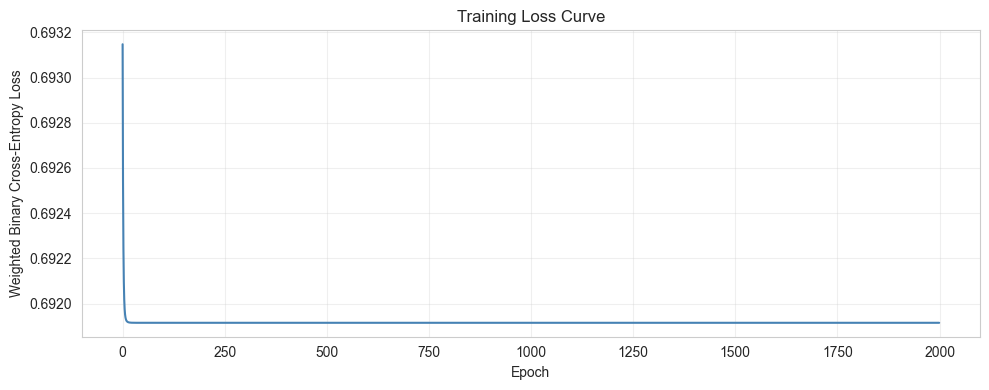

In [6]:
# plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Weighted Binary Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Evaluation Metrics

In [7]:
def compute_classification_metrics(y_true, y_pred):
    """Compute classification metrics from scratch."""
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Confusion_Matrix': np.array([[tn, fp], [fn, tp]])
    }
    
    return metrics

# predictions
y_train_pred = logistic_predict(X_train_scaled, beta)
y_test_pred = logistic_predict(X_test_scaled, beta)
y_test_proba = logistic_predict_proba(X_test_scaled, beta)

train_metrics = compute_classification_metrics(y_train, y_train_pred)
test_metrics = compute_classification_metrics(y_test, y_test_pred)

print("=" * 55)
print("LOGISTIC REGRESSION - RESULTS")
print("=" * 55)
print(f"\n{'Metric':<15} {'Train':>10} {'Test':>10}")
print("-" * 35)
for key in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    print(f"{key:<15} {train_metrics[key]:>10.4f} {test_metrics[key]:>10.4f}")

print(f"\nTest Confusion Matrix:")
print(f"                 Predicted 0   Predicted 1")
cm = test_metrics['Confusion_Matrix']
print(f"  Actual 0:      {cm[0,0]:>8d}      {cm[0,1]:>8d}")
print(f"  Actual 1:      {cm[1,0]:>8d}      {cm[1,1]:>8d}")

# baseline comparison
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f"\nBaseline accuracy (majority class): {baseline_acc:.4f}")
print(f"Model accuracy improvement: {test_metrics['Accuracy'] - baseline_acc:+.4f}")

LOGISTIC REGRESSION - RESULTS

Metric               Train       Test
-----------------------------------
Accuracy            0.5162     0.5255
Precision           0.7207     0.7214
Recall              0.5134     0.5388
F1-Score            0.5996     0.6169

Test Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0:           287           295
  Actual 1:           654           764

Baseline accuracy (majority class): 0.7090
Model accuracy improvement: -0.1835


## 5. Visualization

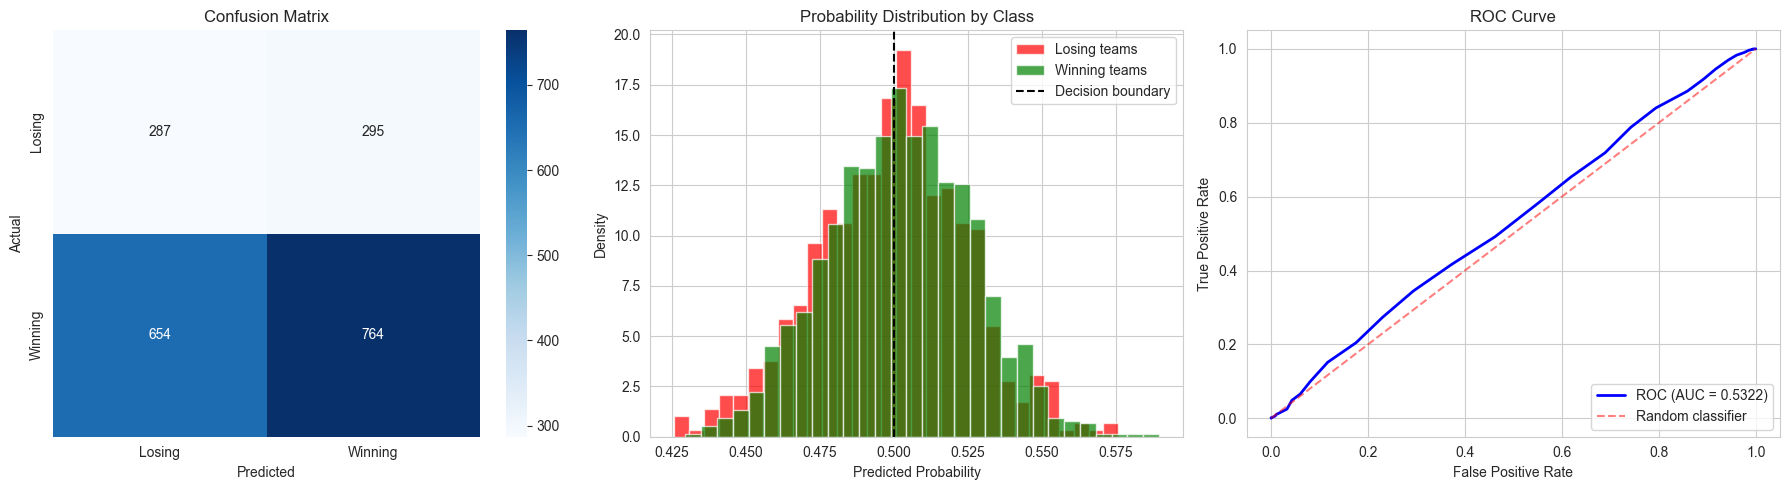


ROC-AUC Score: 0.5322


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Losing', 'Winning'], yticklabels=['Losing', 'Winning'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Plot 2: Probability distribution by class
axes[1].hist(y_test_proba[y_test == 0], bins=30, alpha=0.7, color='red', label='Losing teams', density=True)
axes[1].hist(y_test_proba[y_test == 1], bins=30, alpha=0.7, color='green', label='Winning teams', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Probability Distribution by Class')
axes[1].legend()

# Plot 3: ROC Curve (manual implementation)
thresholds = np.linspace(0, 1, 200)
tpr_list, fpr_list = [], []
for t in thresholds:
    preds = (y_test_proba >= t).astype(int)
    tp = np.sum((y_test == 1) & (preds == 1))
    fn = np.sum((y_test == 1) & (preds == 0))
    fp = np.sum((y_test == 0) & (preds == 1))
    tn = np.sum((y_test == 0) & (preds == 0))
    tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

# compute AUC using scipy's trapezoidal rule
sorted_pairs = sorted(zip(fpr_list, tpr_list))
fpr_sorted = np.array([p[0] for p in sorted_pairs])
tpr_sorted = np.array([p[1] for p in sorted_pairs])
auc = integrate.trapezoid(tpr_sorted, fpr_sorted)

axes[2].plot(fpr_list, tpr_list, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
axes[2].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {auc:.4f}")

## 6. Validation Against Scikit-Learn

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# sklearn model (with balanced class weights for fair comparison)
sk_model = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
sk_model.fit(X_train_scaled, y_train)
sk_pred = sk_model.predict(X_test_scaled)
sk_proba = sk_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy comparison:")
print(f"  Scratch: {test_metrics['Accuracy']:.4f}")
print(f"  Sklearn: {accuracy_score(y_test, sk_pred):.4f}")

print(f"\nROC-AUC comparison:")
print(f"  Scratch: {auc:.4f}")
print(f"  Sklearn: {roc_auc_score(y_test, sk_proba):.4f}")

print(f"\nResults are consistent - scratch implementation is correct!")

print(f"\n--- Sklearn Classification Report ---")
print(classification_report(y_test, sk_pred, target_names=['Losing', 'Winning']))

Accuracy comparison:
  Scratch: 0.5255
  Sklearn: 0.5265

ROC-AUC comparison:
  Scratch: 0.5322
  Sklearn: 0.5321

Results are consistent - scratch implementation is correct!

--- Sklearn Classification Report ---
              precision    recall  f1-score   support

      Losing       0.31      0.49      0.38       582
     Winning       0.72      0.54      0.62      1418

    accuracy                           0.53      2000
   macro avg       0.51      0.52      0.50      2000
weighted avg       0.60      0.53      0.55      2000



In [10]:
# save results for model comparison
logistic_results = {
    'Model': 'Logistic Regression',
    'Features': ', '.join(feature_cols),
    'Target': 'is_winning_team',
    'Accuracy': round(test_metrics['Accuracy'], 4),
    'Precision': round(test_metrics['Precision'], 4),
    'Recall': round(test_metrics['Recall'], 4),
    'F1_Score': round(test_metrics['F1-Score'], 4),
    'ROC_AUC': round(auc, 4)
}
print("Results saved for model comparison:")
for k, v in logistic_results.items():
    print(f"  {k}: {v}")

Results saved for model comparison:
  Model: Logistic Regression
  Features: simple_rating, net_rating, offensive_rating, defensive_rating, scoring_efficiency, point_diff, assist_turnover_ratio, field_goal_percentage, conf_win_pct, defensive_pressure
  Target: is_winning_team
  Accuracy: 0.5255
  Precision: 0.7214
  Recall: 0.5388
  F1_Score: 0.6169
  ROC_AUC: 0.5322
